In [3]:
# pip install langfuse

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
from langfuse import get_client,propagate_attributes,Evaluation

langfuse = get_client()

if not langfuse.auth_check():
    raise RuntimeError("Check that your Langfuse project keys match the configured region.")



## 1. Building the Graph/agent

In [3]:
# build simple Langgraph based agent
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI



/Users/rahultiwari/Documents/02_Freelancing/coding_ninja_fresh/dummy-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os

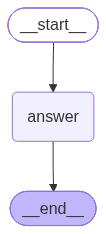

In [7]:
MODEL = os.environ.get("OPENAI_MODEL", "gpt-4o")
llm = ChatOpenAI(model=MODEL, temperature=0.2, timeout=30, max_retries=1)


class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: ChatState, config: RunnableConfig):
    # Forward the graph config so the model inherits tracing callbacks.
    reply = llm.invoke(state["messages"], config=config)
    return {"messages": [reply]}

builder = StateGraph(ChatState)
builder.add_node("answer", chatbot)
builder.add_edge(START, "answer")
builder.add_edge("answer", END)
simple_graph = builder.compile()
simple_graph

In [11]:
## smallest traceable graph : trace
from langfuse.langchain import CallbackHandler


basic_handler = CallbackHandler()
basic_result =  simple_graph.invoke(
    {"messages": [HumanMessage(content="tell me how LLM works")]},
    config={"callbacks": [basic_handler]},
)



In [10]:
basic_handler.last_trace_id

'ec25e82f8ad2de20aeb5444242fc8656'

In [12]:
basic_handler.last_trace_id

'1dc1f7dd6ba3e31ab74d4b9267e42454'

In [15]:
named_handler = CallbackHandler()


with propagate_attributes(
    trace_name="lesson-chat", user_id="demo-student", session_id="lesson-session",
    tags=["teaching-lab", "basic"], metadata={"lesson": "named-tracing"},
):
    named_result = simple_graph.invoke(
        {"messages": [HumanMessage(content="tell me how LLM works for 10 years kid")]},
        config={"callbacks": [named_handler], "run_name": "explain-trace-and-metric"},
    )


In [16]:
named_handler = CallbackHandler()


with propagate_attributes(
    trace_name="lesson-chat", user_id="rahul-demo", session_id="dummy-session",
    tags=["teaching-lab", "basic"], metadata={"lesson": "named-tracing"},
):
    named_result = simple_graph.invoke(
        {"messages": [HumanMessage(content="tell me how LLM works for 10 years kid")]},
        config={"callbacks": [named_handler], "run_name": "explain-trace-and-metric"},
    )
